# Notebook 5: Failure Casebook and Qualitative Sampling

**Goal:** Prepare a dataset for later open coding.

**Inputs:** `failure_cases.csv`, `failure_cases.jsonl`

**RQs addressed:** RQ8

Run the failure export first::

    python -m analysis export-failures --results Output/**/*.csv --out Analysis/output/failures --markdown

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.plots import failure_category_bar
from analysis.schema import PRELIMINARY_FAILURE_LABELS

sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data/failures')
cases_path = DATA_DIR / 'failure_cases.csv'

if not cases_path.exists():
    raise FileNotFoundError(
        f'Missing required failure case CSV: {cases_path}. '
        'Run: python -m analysis export-failures --results ... --out Analysis/data/failures --markdown'
    )

cases = pd.read_csv(cases_path)
print(f'Loaded {len(cases)} failure cases.')

Loaded 6 failure cases.


## 1. Failure Dataset Scope

Counts the exported failure cases by lane and repository. Establishes whether the failure set is representative of the overall attempt distribution — a lane heavily under-represented here may be under-coded in the open-coding phase.


In [2]:
if not cases.empty:
    print(f'Total failure cases: {len(cases)}')
    if 'lane' in cases.columns:
        print('By lane:')
        print(cases['lane'].value_counts())
    if 'repo_name' in cases.columns:
        print('\nRepositories in failure set:')
        print(cases['repo_name'].value_counts())

Total failure cases: 6
By lane:
lane
llm        5
agentic    1
Name: count, dtype: int64

Repositories in failure set:
repo_name
TestMap-Example    6
Name: count, dtype: int64


## 2. Preliminary Machine Labels

Distribution of automatically assigned `preliminary_failure_label` values. These labels are heuristic (rule-based from failure_kind, failure_stage, outcome_classification) and are provided as a starting point for open coding — they should not be reported as final categories without human verification.

**Priority for open coding:** `unclassified` cases have no machine label and should be reviewed first. Labels that appear frequently but may be noisy (e.g., `test_failed` covers many distinct root causes) are secondary priorities.


In [3]:
if not cases.empty and 'preliminary_failure_label' in cases.columns:
    label_counts = cases['preliminary_failure_label'].value_counts()
    print('Preliminary label distribution:')
    print(label_counts)

    # Flag labels not in schema
    unexpected = set(label_counts.index) - set(PRELIMINARY_FAILURE_LABELS)
    if unexpected:
        print(f'\nUnexpected labels (not in schema): {unexpected}')

Preliminary label distribution:
preliminary_failure_label
test_failed     4
unclassified    2
Name: count, dtype: int64


## 3. Failure Category Counts

Grouped bar chart of preliminary label counts by lane (and by tool for agentic cases). Reveals whether certain failure modes are lane-specific or tool-specific, which informs where to focus qualitative analysis.


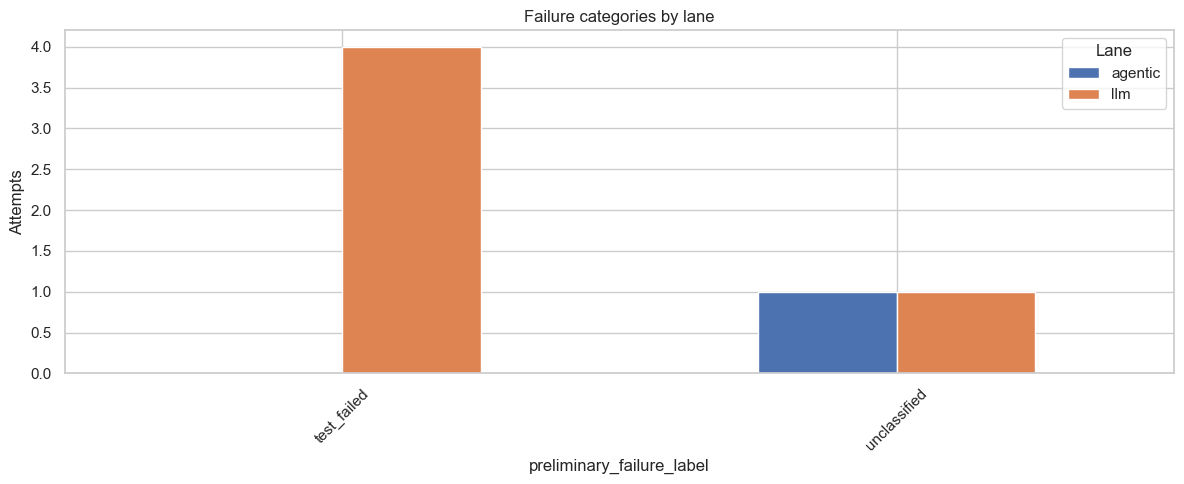

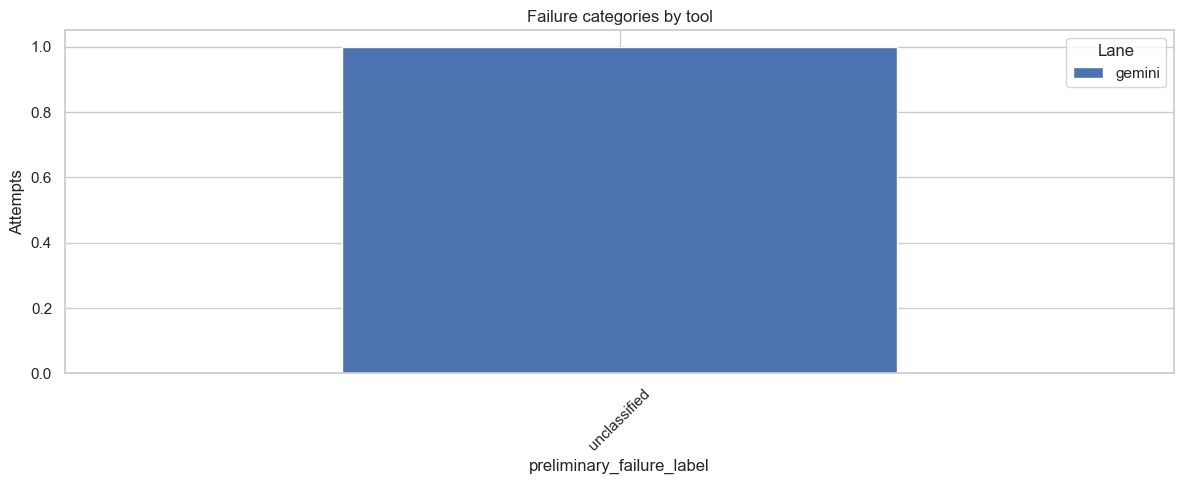

In [4]:
if not cases.empty and 'preliminary_failure_label' in cases.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    failure_category_bar(cases, lane_col='lane', category_col='preliminary_failure_label', ax=ax)
    plt.tight_layout()
    plt.show()

    if 'tool_id' in cases.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        failure_category_bar(cases, lane_col='tool_id', category_col='preliminary_failure_label', ax=ax)
        ax.set_title('Failure categories by tool')
        plt.tight_layout()
        plt.show()

## 4. Stratified Sampling Plan

Selects a balanced sample across failure labels (up to N cases per label) for open coding. Stratifying by label ensures rare failure types receive at least one representative case rather than being crowded out by the most common label. The resulting sample is the recommended starting set for qualitative coding.


In [5]:
from analysis.export_failure_cases import sample_cases

if not cases.empty:
    # Stratified by label: 5 per label
    stratified = sample_cases(cases, strategy='stratified-label', top_n=5)
    print(f'Stratified sample size: {len(stratified)}')
    if 'preliminary_failure_label' in stratified.columns:
        print(stratified['preliminary_failure_label'].value_counts())

Stratified sample size: 6

## 5. Paired Disagreement Cases

Identifies candidates where one lane succeeded and the other failed (`llm_won` or `agentic_won` in the paired comparison). These cases are the most informative for understanding lane-specific strengths and weaknesses because the target method is held constant.


In [6]:
# Cases where one lane failed and the other succeeded for the same candidate
if not cases.empty and 'candidate_key' in cases.columns and 'lane' in cases.columns:
    attempts_path = DATA_DIR.parent / 'evaluation_candidates.csv'
    if attempts_path.exists():
        cands = pd.read_csv(attempts_path)
        from analysis.normalize import build_paired_comparison
        paired = build_paired_comparison(cands)
        disagreements = paired[paired['winner'].isin(['llm_won', 'agentic_won'])]
        print(f'Disagreement pairs: {len(disagreements)}')
        display(disagreements[['candidate_key', 'winner', 'llm_validated_success', 'agentic_validated_success']].head(10))
    else:
        print('evaluation_candidates.csv not found.')

Disagreement pairs: 1


,candidate_key,winner,llm_validated_success,agentic_validated_success
0,consulthunter|TestMap-Example|867ab17d3141bc0e...,agentic_won,False,True


## 6. High-Severity Failures

Cases flagged as high-severity (e.g., production code modified, project file modified, constraint violation). These represent correctness or safety risks beyond ordinary test-generation failure and warrant priority review regardless of label distribution.


In [7]:
from analysis.export_failure_cases import sample_cases

if not cases.empty:
    severe = sample_cases(cases, strategy='high-severity')
    print(f'High-severity cases: {len(severe)}')
    cols = [c for c in ['failure_case_id', 'lane', 'tool_id', 'preliminary_failure_label',
                         'source_method_name', 'outcome_summary'] if c in severe.columns]
    display(severe[cols].head(20))

High-severity cases: 0


,failure_case_id,lane,tool_id,preliminary_failure_label,source_method_name


## 7. Exported Case Files

Lists the Markdown case files written by `export-failures --markdown`. Each `case.md` contains the failure metadata, artifact table, and blank open-coding fields (`Open code 1–3`, `Coder`, `Coded at`) to be filled in during qualitative review. Re-run `export-failures --markdown` if no files appear here.


In [8]:
md_dir = DATA_DIR / 'cases'
if md_dir.exists():
    md_files = list(md_dir.glob('case_*/case.md'))
    print(f'Markdown case files: {len(md_files)}')
    if md_files:
        print('Sample:')
        print(md_files[0].read_text()[:800])
else:
    print('No markdown case files found.')
    print('Re-run export with: python -m analysis export-failures ... --markdown')

Markdown case files: 1
Sample:
# Failure Case 1

**Repo:** example/RepoAlpha
**Commit:** abc123
**Lane:** mixed fixture
**Source method:** `ParseLine`
**Failure label:** `test_failed`

## Outcome Summary

Tiny checked-in fixture for notebook smoke runs. It represents one failed LLM attempt, one low-impact passing agentic attempt, and one timed-out agentic attempt in the CSV exports.

## Open Coding Notes

- **Open code 1:**
- **Open code 2:**
- **Open code 3:**



## 8. Outcome Classification in Failure Cases

Joins failure cases with the attempt-level outcome_classification to show the full taxonomy within the failure set. Useful for checking that the preliminary labels agree with the authoritative outcome classification.


Outcome classification in failure set:
outcome_classification
FailedEvidencePositive    4
ValidationFailed          2
Name: count, dtype: int64



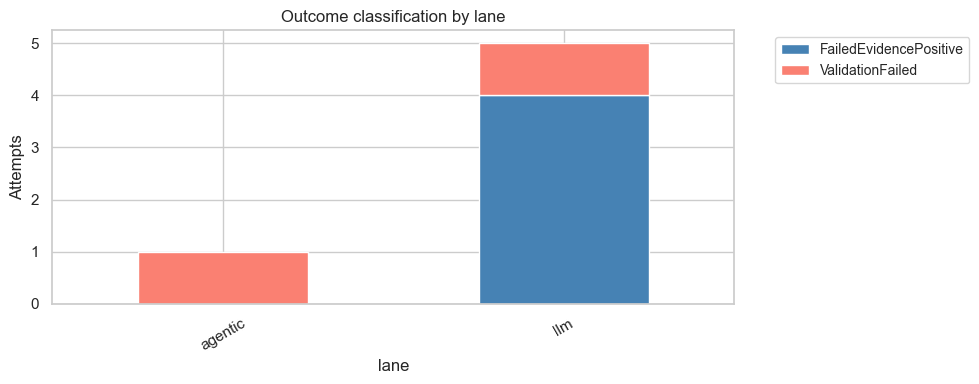

In [9]:
attempts_path = DATA_DIR.parent / 'evaluation_attempts.csv'
if not cases.empty and attempts_path.exists():
    _attempts = pd.read_csv(attempts_path)
    oc_col = 'outcome_classification'
    if oc_col in _attempts.columns and 'attempt_id' in cases.columns and 'attempt_id' in _attempts.columns:
        if oc_col not in cases.columns:
            cases = cases.merge(
                _attempts[['attempt_id', oc_col]].drop_duplicates('attempt_id'),
                on='attempt_id', how='left',
            )

    if oc_col in cases.columns:
        print('Outcome classification in failure set:')
        print(cases[oc_col].value_counts())
        print()

        from analysis.plots import outcome_classification_bar
        fig, ax = plt.subplots(figsize=(10, 4))
        outcome_classification_bar(cases, group_col='lane', outcome_col=oc_col, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        print(f'{oc_col} not available — merge requires attempt_id in both datasets.')
else:
    print('No failure cases or evaluation_attempts.csv available.')

## 9. Test Smells in Failure Cases

Checks whether failures are disproportionately associated with test smells in the generated code. A high smell count in the failure set (vs the overall attempt set) would suggest smell-inducing generation patterns are also associated with test failures.


Generated smells in failures: total=11, cases with smells=6/6
Baseline smells in failures: total=0, cases with smells=0/6


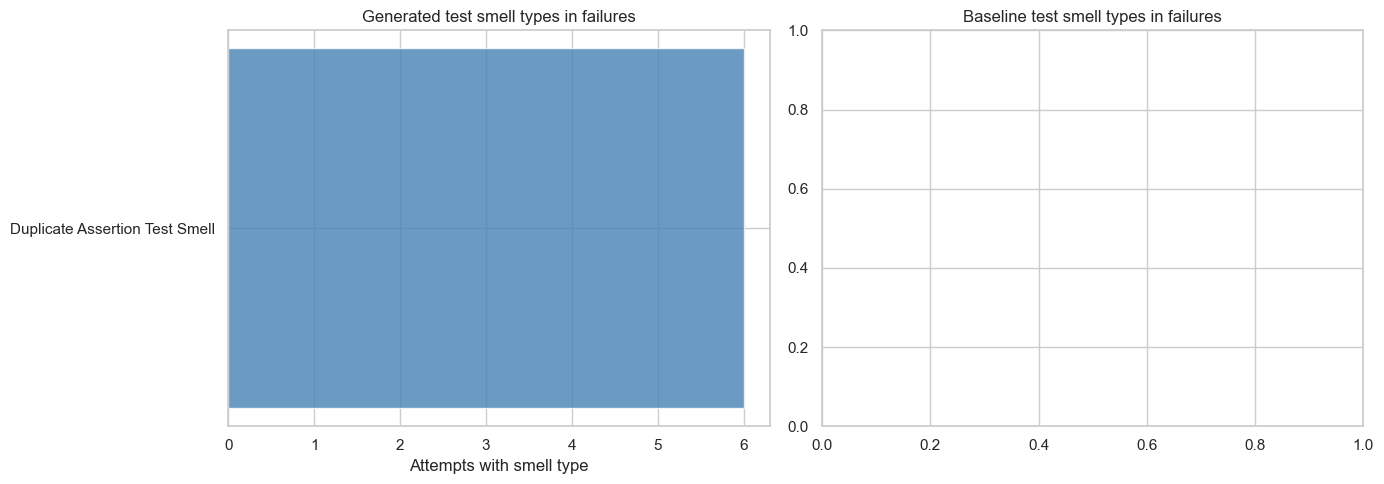

In [10]:
attempts_path = DATA_DIR.parent / 'evaluation_attempts.csv'
if not cases.empty and attempts_path.exists():
    _attempts = pd.read_csv(attempts_path)
    smell_cols_to_merge = [c for c in [
        'attempt_id', 'generated_test_smell_count', 'generated_test_smell_types',
        'baseline_test_smell_count', 'baseline_test_smell_types',
    ] if c in _attempts.columns]
    if len(smell_cols_to_merge) > 1 and 'attempt_id' in cases.columns:
        missing = [c for c in smell_cols_to_merge[1:] if c not in cases.columns]
        if missing:
            cases = cases.merge(
                _attempts[smell_cols_to_merge].drop_duplicates('attempt_id'),
                on='attempt_id', how='left',
            )

    for count_col, types_col, label in [
        ('generated_test_smell_count', 'generated_test_smell_types', 'Generated'),
        ('baseline_test_smell_count',  'baseline_test_smell_types',  'Baseline'),
    ]:
        if count_col in cases.columns:
            total = cases[count_col].fillna(0).sum()
            with_smells = (cases[count_col].fillna(0) > 0).sum()
            print(f'{label} smells in failures: total={int(total)}, cases with smells={with_smells}/{len(cases)}')

    from analysis.plots import smell_type_breakdown
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    smell_type_breakdown(cases, 'generated_test_smell_types', ax=axes[0])
    axes[0].set_title('Generated test smell types in failures')
    smell_type_breakdown(cases, 'baseline_test_smell_types',  ax=axes[1])
    axes[1].set_title('Baseline test smell types in failures')
    plt.tight_layout()
    plt.show()
else:
    print('No failure cases or attempts CSV available.')